# Unified Firing Rate Analysis
PSTH plots (raw + baseline-subtracted) + baseline firing rate correlation with LDA 1

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from scipy.stats import pearsonr, spearmanr
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

In [100]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/'

# Load LDA
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026')
lda = lda.rename(columns={0: 'lda_1', 1: 'lda_2'})

# binned1 is a categorical of interval objects (e.g. (-4.154, -0.851]).
# Convert to ordinal integer codes 0-4 (ordered low->high LDA) so downstream
# code that loops over range(5) works.
lda['binned1'] = lda['binned1'].cat.codes

print(f"LDA shape: {lda.shape}")
print(f"Sessions: {lda['session'].nunique()}")
print(f"binned1 codes: {sorted(lda['binned1'].unique())}")

LDA shape: (248, 31)
Sessions: 248
binned1 codes: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]


In [101]:
# Get time column structure from first file
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    sample_data = pickle.load(f)

time_cols = [col for col in sample_data.columns if col.startswith('t_')]
time_cols = sorted(time_cols, key=lambda x: float(x.split('_')[1]))
time_values = np.array([float(col.split('_')[1]) for col in time_cols])

print(f"Time columns: {len(time_cols)}")
print(f"Time range: {time_values.min():.3f} to {time_values.max():.3f} seconds")

# Baseline window
baseline_mask = (time_values >= -0.2) & (time_values <= 0)
baseline_cols = [col for col, mask in zip(time_cols, baseline_mask) if mask]
print(f"\nBaseline window: -0.2 to 0 seconds ({len(baseline_cols)} bins)")

Time columns: 90
Time range: -0.500 to 1.000 seconds

Baseline window: -0.2 to 0 seconds (12 bins)


In [102]:
# Load all files -> per-neuron PSTHs (raw + baseline-subtracted) with per-neuron metadata.
# Everything downstream (PSTHs at neuron/probe/session level AND the baseline correlation)
# is derived from this single per-neuron store, so one region filter flows through all of it.
print("Loading firing rates...\n")

bin_map = {s: b for s, b in zip(lda['session'], lda['binned1']) if b >= 0}

neuron_raw_list = []   # list of (n_neurons x n_time) arrays
neuron_sub_list = []
meta_list = []         # per-neuron metadata frames

for i, pkl_file in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, pkl_file), 'rb') as f:
            data = pickle.load(f)

        data['baseline_fr'] = np.nanmean(data[baseline_cols].values, axis=1)
        session = data['session'].iloc[0]
        b = bin_map.get(session, None)
        if b is None:
            continue  # session has no LDA bin

        grp = data.groupby('neuron_id')
        g_raw = grp[time_cols].mean()                 # n_neurons x n_time (mean across trials)
        g_bl = grp['baseline_fr'].mean()              # n_neurons
        g_sub = g_raw.sub(g_bl, axis=0)

        m = grp.agg(area=('area', 'first'), pid=('pid', 'first')).reset_index()
        m['baseline_fr'] = g_bl.values
        m['session'] = session
        m['bin'] = int(b)

        neuron_raw_list.append(g_raw.values)
        neuron_sub_list.append(g_sub.values)
        meta_list.append(m)

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(pkl_files)} files...")

    except Exception as e:
        print(f"Error loading {pkl_file}: {e}")

neuron_raw_all = np.vstack(neuron_raw_list)           # N x T
neuron_sub_all = np.vstack(neuron_sub_list)
neuron_meta_all = pd.concat(meta_list, ignore_index=True)   # N rows: session, pid, area, bin, baseline_fr

print(f"\n✓ Loaded {neuron_raw_all.shape[0]} neurons from {neuron_meta_all['session'].nunique()} sessions")
print(f"  Distinct areas: {neuron_meta_all['area'].nunique()}; top: "
      f"{neuron_meta_all['area'].value_counts().head(3).to_dict()}")

Loading firing rates...

Processed 50/380 files...
Processed 100/380 files...
Processed 150/380 files...
Processed 200/380 files...
Processed 250/380 files...
Processed 300/380 files...
Processed 350/380 files...

✓ Loaded 65374 neurons from 244 sessions
  Distinct areas: 250; top: {'root': 30716, 'CP': 2024, 'PO': 1131}


In [103]:
# ============================================================
# REGION FILTER  — choose which neurons enter ALL downstream analyses
#   'all'       -> keep everything
#   'drop_root' -> drop unlocalized 'root' channels
#   'list'      -> keep only the BRAIN_REGIONS below
# ============================================================
REGION_MODE = 'drop_root'
BRAIN_REGIONS = ['CA1', 'DG', 'MRN', 'CP', 'LP', 'CA3']  # ZI PO

area = neuron_meta_all['area']
if REGION_MODE == 'all':
    mask = np.ones(len(area), dtype=bool)
elif REGION_MODE == 'drop_root':
    mask = (area != 'root').values
elif REGION_MODE == 'list':
    mask = area.isin(BRAIN_REGIONS).values
else:
    raise ValueError(f"Unknown REGION_MODE: {REGION_MODE}")

# Filtered per-neuron store used by every analysis below
neuron_raw = neuron_raw_all[mask]
neuron_sub = neuron_sub_all[mask]
neuron_meta = neuron_meta_all[mask].reset_index(drop=True)

print(f"Region filter '{REGION_MODE}': kept {mask.sum()} / {len(mask)} neurons")
print(f"  Sessions remaining: {neuron_meta['session'].nunique()}")
print(f"  Areas kept: {sorted(neuron_meta['area'].unique())}")

Region filter 'drop_root': kept 34658 / 65374 neurons
  Sessions remaining: 244
  Areas kept: ['AAA', 'ACAd', 'ACAv', 'ACB', 'AD', 'ADP', 'AHN', 'AId', 'AIp', 'AIv', 'AM', 'ANcr1', 'ANcr2', 'AON', 'AP', 'APN', 'APr', 'AT', 'AUDd', 'AUDp', 'AUDpo', 'AUDv', 'AV', 'AVP', 'BLA', 'BMA', 'BST', 'CA1', 'CA2', 'CA3', 'CEA', 'CENT2', 'CENT3', 'CL', 'CLA', 'CLI', 'CM', 'COAa', 'COAp', 'COPY', 'CP', 'CS', 'CU', 'CUL4 5', 'CUN', 'DCO', 'DEC', 'DG', 'DMH', 'DMX', 'DN', 'DP', 'DT', 'DTN', 'ECT', 'ECU', 'ENTl', 'ENTm', 'EPd', 'EPv', 'Eth', 'FC', 'FL', 'FN', 'FOTU', 'FRP', 'FS', 'GPe', 'GPi', 'GR', 'GRN', 'GU', 'HATA', 'I5', 'IAD', 'IC', 'ICB', 'IGL', 'III', 'ILA', 'IMD', 'IP', 'IRN', 'ISN', 'IntG', 'LA', 'LAV', 'LD', 'LDT', 'LGd', 'LGv', 'LH', 'LHA', 'LIN', 'LING', 'LP', 'LPO', 'LRN', 'LSc', 'LSr', 'LSv', 'MA', 'MARN', 'MD', 'MDRN', 'MEA', 'MEPO', 'MG', 'MH', 'MOB', 'MOp', 'MOs', 'MPN', 'MPO', 'MRN', 'MS', 'MV', 'NB', 'NDB', 'NI', 'NLL', 'NOD', 'NOT', 'NPC', 'NTS', 'OP', 'ORBl', 'ORBm', 'ORBvl', 'OT'

In [104]:
# ============================================================
# CHOOSE THE AGGREGATION UNIT FOR THE BASELINE-vs-LDA ANALYSIS
#   'neuron'  -> one point per neuron      (largest n, pseudoreplicated)
#   'probe'   -> one point per probe-file  (each probe weighted equally)
#   'session' -> one point per session     (most conservative)
# (All built from the region-filtered neurons above.)
# ============================================================
AGG_LEVEL = 'session'

nm = neuron_meta
baseline_tables = {
    'neuron':  nm[['session', 'baseline_fr']].rename(columns={'baseline_fr': 'baseline_fr_mean'}),
    'probe':   (nm.groupby(['session', 'pid'], as_index=False)['baseline_fr'].mean()
                  .rename(columns={'baseline_fr': 'baseline_fr_mean'})[['session', 'baseline_fr_mean']]),
    'session': (nm.groupby('session', as_index=False)['baseline_fr'].mean()
                  .rename(columns={'baseline_fr': 'baseline_fr_mean'})),
}
baseline_sel = baseline_tables[AGG_LEVEL].copy()

print(f"Aggregation level: '{AGG_LEVEL}'  ->  n units = {len(baseline_sel)}")
print(f"  Mean baseline FR: {baseline_sel['baseline_fr_mean'].mean():.2f} Hz")
print(f"  Range: [{baseline_sel['baseline_fr_mean'].min():.2f}, {baseline_sel['baseline_fr_mean'].max():.2f}] Hz")

Aggregation level: 'session'  ->  n units = 244
  Mean baseline FR: 10.07 Hz
  Range: [0.34, 40.71] Hz


In [105]:
# Merge selected-level baseline with LDA
baseline_with_lda = baseline_sel.merge(lda[['session', 'lda_1', 'lda_2', 'binned1']], on='session', how='inner')

print(f"✓ Merged baseline ('{AGG_LEVEL}' level) with LDA: {baseline_with_lda.shape}")
print(f"\nFirst 5 rows:")
print(baseline_with_lda[['session', 'baseline_fr_mean', 'lda_1', 'binned1']].head())

✓ Merged baseline ('session' level) with LDA: (244, 5)

First 5 rows:
                                session  baseline_fr_mean     lda_1  binned1
0  032452e9-1886-449d-9c13-0f192572e19f          4.356595 -1.830125        1
1  034e726f-b35f-41e0-8d6c-a22cc32391fb          8.525641 -3.780343        1
2  09156021-9a1d-4e1d-ae59-48cbde3c5d42          5.264705 -4.328472        0
3  09394481-8dd2-4d5c-9327-f2753ede92d7         14.231860  1.521032        2
4  09b2c4d1-058d-4c84-9fd4-97530f85baf6         11.291750  1.788832        2


## PSTH by LDA Bin (Raw vs Baseline-Subtracted)

In [106]:
# Build three PSTH aggregations per bin, all with SEM, from the region-filtered neurons:
#   (A) NEURON-POOLED  : mean & SEM across neurons
#   (B) PROBE-WEIGHTED : per-probe mean, then mean & SEM across probe-files
#   (C) SESSION-FIRST  : per-session mean, then mean & SEM across sessions
def mean_sem(mat):
    n = mat.shape[0]
    mean = np.nanmean(mat, axis=0)
    sem = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(mean)
    return mean, sem, n

bins_arr = neuron_meta['bin'].values
sess_arr = neuron_meta['session'].values
probe_key = (neuron_meta['session'].astype(str) + '__' + neuron_meta['pid'].astype(str)).values

# (A) neuron-pooled
neuron_stats_raw, neuron_stats_sub = {}, {}
for b in range(5):
    m = bins_arr == b
    if m.sum() > 0:
        neuron_stats_raw[b] = mean_sem(neuron_raw[m])
        neuron_stats_sub[b] = mean_sem(neuron_sub[m])

# (B) probe-weighted: collapse to one vector per probe-file first
uprobes, inv = np.unique(probe_key, return_inverse=True)
probe_raw = np.vstack([np.nanmean(neuron_raw[inv == k], axis=0) for k in range(len(uprobes))])
probe_sub = np.vstack([np.nanmean(neuron_sub[inv == k], axis=0) for k in range(len(uprobes))])
probe_bin = np.array([bins_arr[inv == k][0] for k in range(len(uprobes))])
probe_stats_raw, probe_stats_sub = {}, {}
for b in range(5):
    m = probe_bin == b
    if m.sum() > 0:
        probe_stats_raw[b] = mean_sem(probe_raw[m])
        probe_stats_sub[b] = mean_sem(probe_sub[m])

# (C) session-first: collapse to one vector per session first
usess = np.unique(sess_arr)
sess_raw = np.vstack([np.nanmean(neuron_raw[sess_arr == s], axis=0) for s in usess])
sess_sub = np.vstack([np.nanmean(neuron_sub[sess_arr == s], axis=0) for s in usess])
sess_bin = np.array([bins_arr[sess_arr == s][0] for s in usess])
session_stats_raw, session_stats_sub = {}, {}
for b in range(5):
    m = sess_bin == b
    if m.sum() > 0:
        session_stats_raw[b] = mean_sem(sess_raw[m])
        session_stats_sub[b] = mean_sem(sess_sub[m])

print("Per-bin counts (after region filter):")
print("  bin :  n_neurons   n_probes   n_sessions")
for b in range(5):
    nn = neuron_stats_raw[b][2] if b in neuron_stats_raw else 0
    npb = probe_stats_raw[b][2] if b in probe_stats_raw else 0
    ns = session_stats_raw[b][2] if b in session_stats_raw else 0
    print(f"   {b}  :  {nn:8d}   {npb:8d}   {ns:8d}")

Per-bin counts (after region filter):
  bin :  n_neurons   n_probes   n_sessions
   0  :      6790         71         47
   1  :     10534        128         81
   2  :      8886         92         58
   3  :      5929         67         44
   4  :      2519         22         14


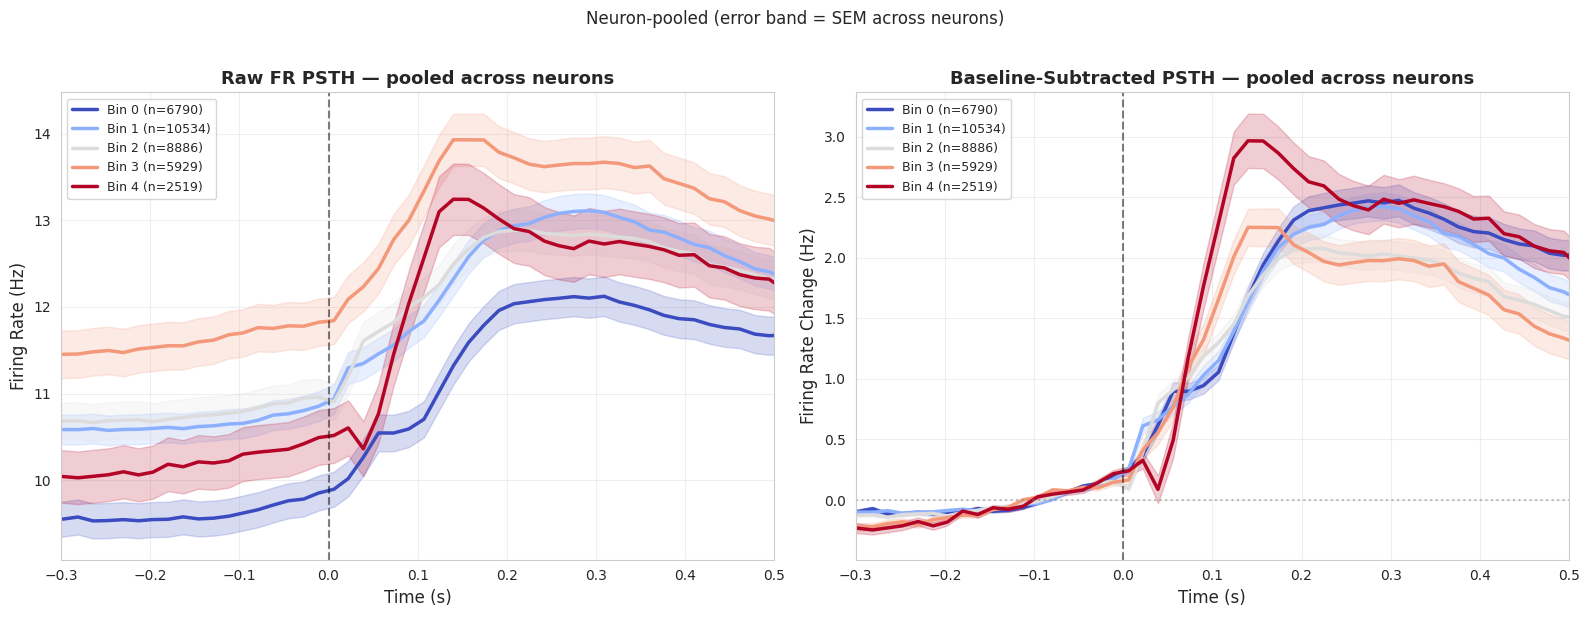

In [107]:
# PLOT A: NEURON-POOLED PSTH — mean +/- SEM across all neurons in each bin
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, 5))

for ax, stats_dict, title, ylabel in [
    (axes[0], neuron_stats_raw, 'Raw FR PSTH — pooled across neurons', 'Firing Rate (Hz)'),
    (axes[1], neuron_stats_sub, 'Baseline-Subtracted PSTH — pooled across neurons', 'Firing Rate Change (Hz)'),
]:
    for b in range(5):
        if b not in stats_dict:
            continue
        mean, sem, n = stats_dict[b]
        ax.plot(time_values, mean, color=colors[b], linewidth=2.5, label=f'Bin {b} (n={n})')
        ax.fill_between(time_values, mean - sem, mean + sem, color=colors[b], alpha=0.2)

    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    if 'Subtracted' in title:
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.3, 0.5])

fig.suptitle('Neuron-pooled (error band = SEM across neurons)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

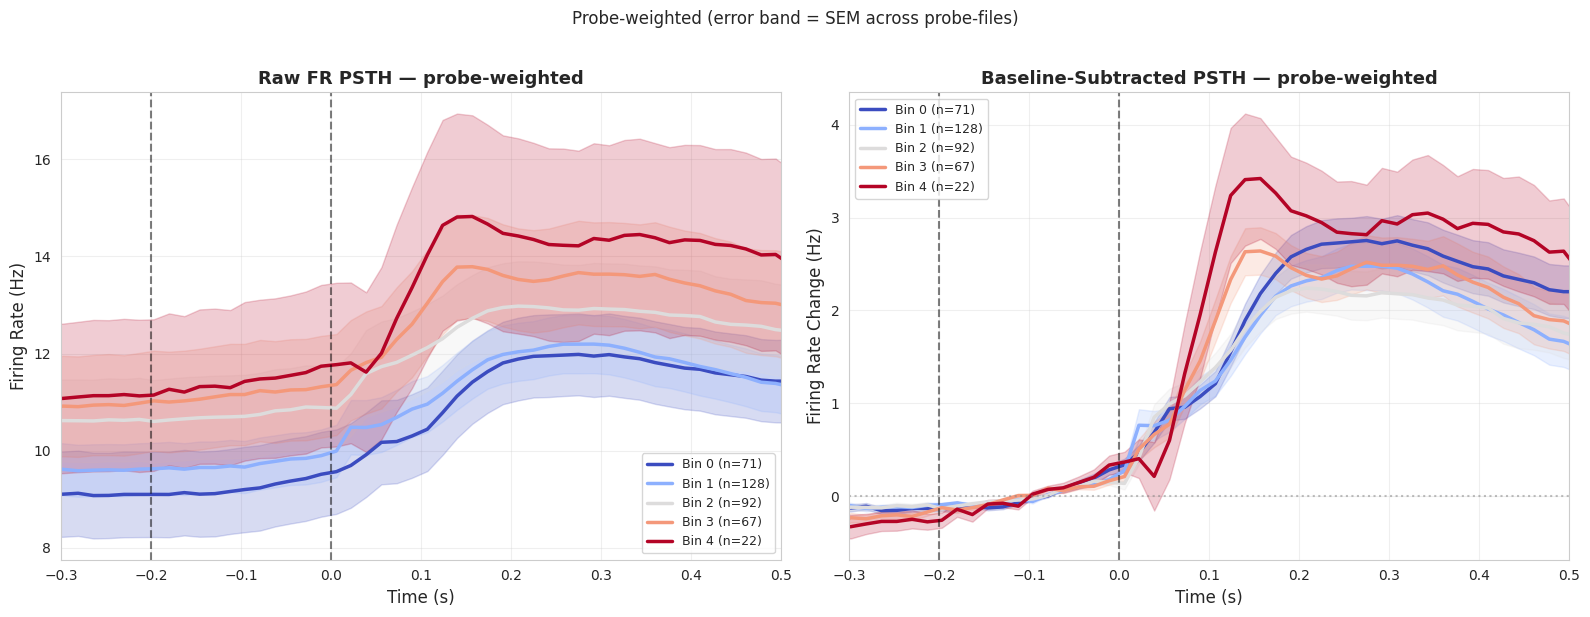

In [108]:
# PLOT: PROBE-WEIGHTED PSTH — mean +/- SEM across probe-files (each probe weighted equally)
# This is the aggregation the ORIGINAL script used.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, 5))

for ax, stats_dict, title, ylabel in [
    (axes[0], probe_stats_raw, 'Raw FR PSTH — probe-weighted', 'Firing Rate (Hz)'),
    (axes[1], probe_stats_sub, 'Baseline-Subtracted PSTH — probe-weighted', 'Firing Rate Change (Hz)'),
]:
    for b in range(5):
        if b not in stats_dict:
            continue
        mean, sem, n = stats_dict[b]
        ax.plot(time_values, mean, color=colors[b], linewidth=2.5, label=f'Bin {b} (n={n})')
        ax.fill_between(time_values, mean - sem, mean + sem, color=colors[b], alpha=0.2)

    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axvline(-0.2, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    if 'Subtracted' in title:
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.3, 0.5])

fig.suptitle('Probe-weighted (error band = SEM across probe-files)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

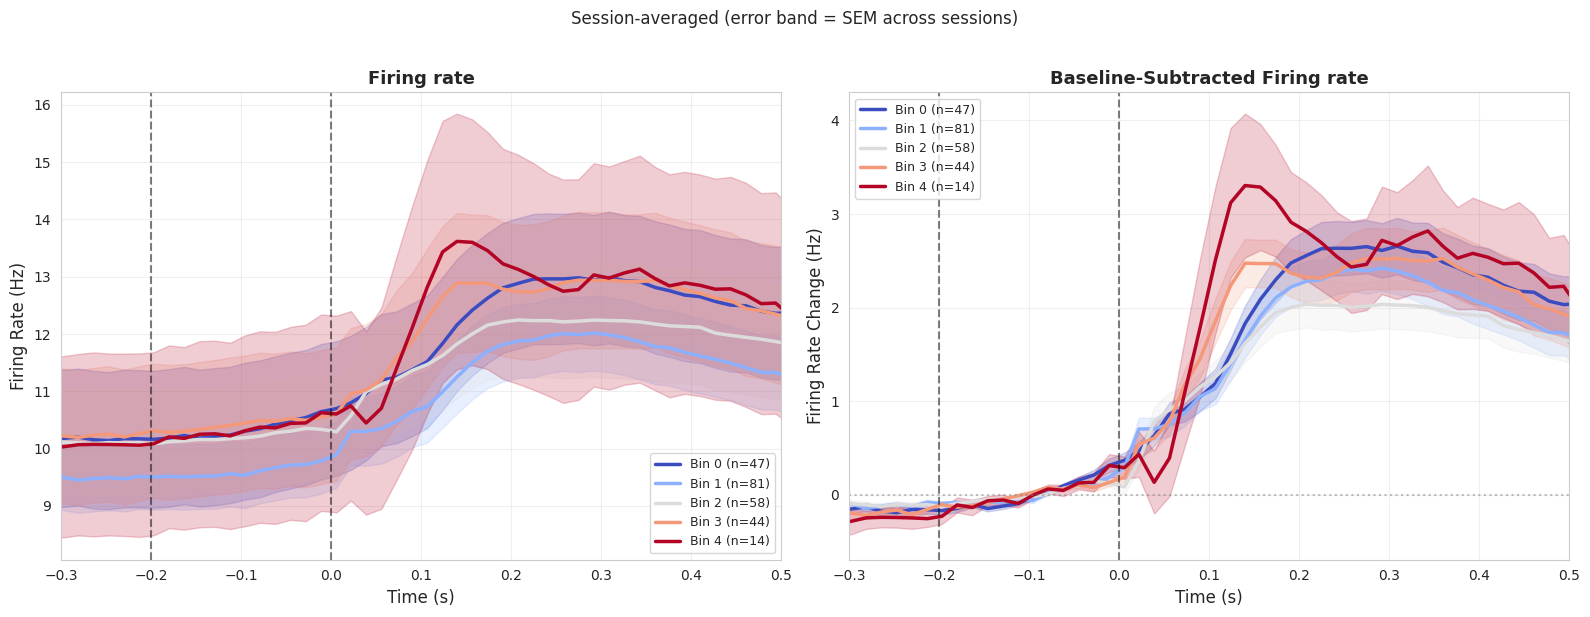

In [110]:
# PLOT B: SESSION-FIRST PSTH — average within session, then mean +/- SEM across sessions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, 5))

for ax, stats_dict, title, ylabel in [
    (axes[0], session_stats_raw, 'Firing rate', 'Firing Rate (Hz)'),
    (axes[1], session_stats_sub, 'Baseline-Subtracted Firing rate', 'Firing Rate Change (Hz)'),
]:
    for b in range(5):
        if b not in stats_dict:
            continue
        mean, sem, n = stats_dict[b]
        ax.plot(time_values, mean, color=colors[b], linewidth=2.5, label=f'Bin {b} (n={n})')
        ax.fill_between(time_values, mean - sem, mean + sem, color=colors[b], alpha=0.2)

    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axvline(-.2, color='black', linestyle='--', alpha=0.5, linewidth=1.5)

    if 'Subtracted' in title:
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.3, 0.5])

fig.suptitle('Session-averaged (error band = SEM across sessions)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

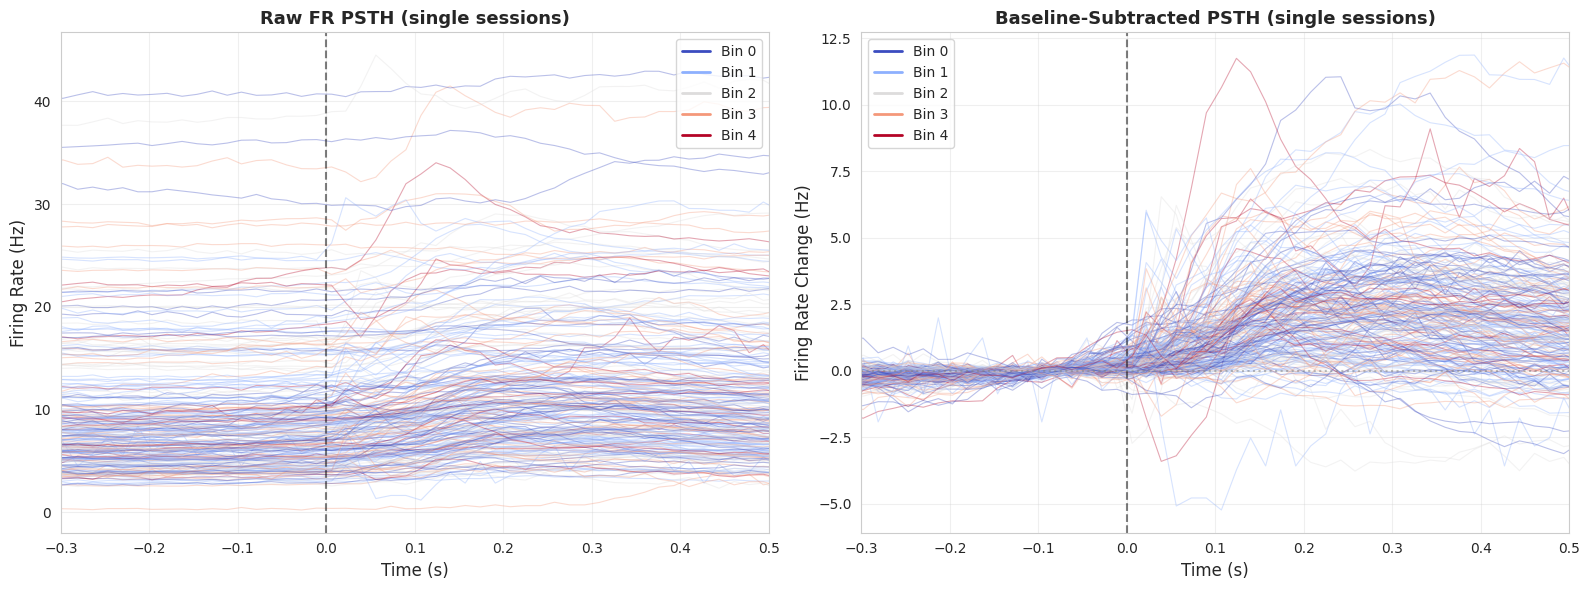

In [111]:
# Single-session PSTH traces, colored by LDA bin (no error bars)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, 5))

for ax, mat, title, ylabel in [
    (axes[0], sess_raw, 'Raw FR PSTH (single sessions)', 'Firing Rate (Hz)'),
    (axes[1], sess_sub, 'Baseline-Subtracted PSTH (single sessions)', 'Firing Rate Change (Hz)'),
]:
    for i in range(mat.shape[0]):
        ax.plot(time_values, mat[i], color=colors[sess_bin[i]], linewidth=0.8, alpha=0.35)

    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    if 'Subtracted' in title:
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.3, 0.5])
    legend_handles = [Line2D([0], [0], color=colors[b], lw=2, label=f'Bin {b}') for b in range(5)]
    ax.legend(handles=legend_handles, fontsize=10, loc='best')

plt.tight_layout()
plt.show()

## Baseline Firing Rate Correlation with LDA 1

In [112]:
# Correlation analysis (at the chosen aggregation level)
valid_data = baseline_with_lda[['baseline_fr_mean', 'lda_1']].dropna()

r_pearson, p_pearson = pearsonr(valid_data['baseline_fr_mean'], valid_data['lda_1'])
rho_spearman, p_spearman = spearmanr(valid_data['baseline_fr_mean'], valid_data['lda_1'])

print("\n" + "="*70)
print(f"CORRELATION: Baseline Firing Rate vs LDA 1  ('{AGG_LEVEL}' level)")
print("="*70)
print(f"n_units:        {len(valid_data)}")
print(f"pearson_r:      {r_pearson:.4f}")
print(f"pearson_p:      {p_pearson:.4e}")
print(f"spearman_rho:   {rho_spearman:.4f}")
print(f"spearman_p:     {p_spearman:.4e}")
print(f"\nBaseline FR - Mean: {valid_data['baseline_fr_mean'].mean():.2f} Hz")
print(f"                 SD: {valid_data['baseline_fr_mean'].std():.2f} Hz")


CORRELATION: Baseline Firing Rate vs LDA 1  ('session' level)
n_units:        244
pearson_r:      0.0516
pearson_p:      4.2217e-01
spearman_rho:   0.0299
spearman_p:     6.4165e-01

Baseline FR - Mean: 10.07 Hz
                 SD: 6.74 Hz


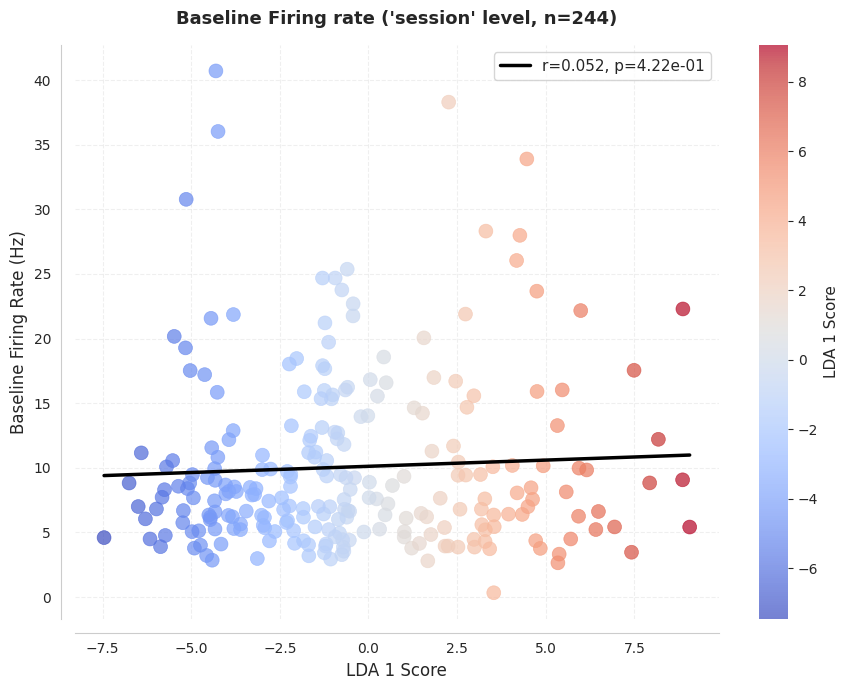

In [113]:
# Plot baseline FR vs LDA 1 (at the chosen aggregation level)
fig, ax = plt.subplots(figsize=(9, 7))

x = valid_data['lda_1'].values
y = valid_data['baseline_fr_mean'].values

# Scatter with color gradient
sc = ax.scatter(x, y, c=x, cmap='coolwarm', alpha=0.7, s=100,  linewidth=0.5)

# Linear regression
z = np.polyfit(x, y, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p_fit(x_line), 'r-', linewidth=2.5, 
        label=f'r={r_pearson:.3f}, p={p_pearson:.2e}', color='black')

# Colorbar
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('LDA 1 Score', fontsize=11)
cbar.outline.set_visible(False)

# Labels
ax.set_xlabel('LDA 1 Score', fontsize=12)
ax.set_ylabel('Baseline Firing Rate (Hz)', fontsize=12)
ax.set_title(f"Baseline Firing rate ('{AGG_LEVEL}' level, n={len(valid_data)})",
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(ax=ax, offset=10)

plt.tight_layout()
plt.show()

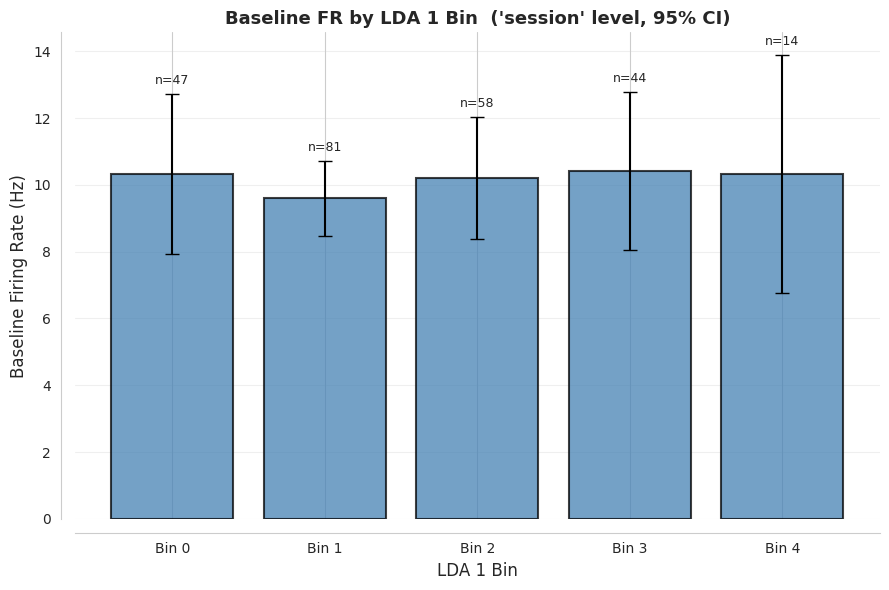

In [114]:
# Baseline FR by LDA bin (error bars = 95% CI), at the chosen aggregation level
fig, ax = plt.subplots(figsize=(9, 6))

bin_data = baseline_with_lda.groupby('binned1')['baseline_fr_mean'].agg(['mean', 'std', 'count'])

# 95% CI half-width (t-based, since some bins have small n)
bin_data['sem'] = bin_data['std'] / np.sqrt(bin_data['count'])
bin_data['ci95'] = bin_data.apply(
    lambda r: stats.t.ppf(0.975, r['count'] - 1) * r['sem'] if r['count'] > 1 else 0.0,
    axis=1
)

x_pos = np.arange(len(bin_data))

ax.bar(x_pos, bin_data['mean'], yerr=bin_data['ci95'], 
       capsize=5, alpha=0.75, color='steelblue', edgecolor='black', linewidth=1.5)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Bin {i}' for i in range(len(bin_data))])
ax.set_xlabel('LDA 1 Bin', fontsize=12)
ax.set_ylabel('Baseline Firing Rate (Hz)', fontsize=12)
ax.set_title(f"Baseline FR by LDA 1 Bin  ('{AGG_LEVEL}' level, 95% CI)", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
sns.despine(ax=ax, offset=10)

# Add sample sizes
for i, (mean, ci, count) in enumerate(zip(bin_data['mean'], bin_data['ci95'], bin_data['count'])):
    ax.text(i, mean + ci + 0.3, f'n={int(count)}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [115]:
print("\n" + "="*70)
print(f"SUMMARY STATISTICS  ('{AGG_LEVEL}' level)")
print("="*70)

print(f"\nBaseline Firing Rate Summary (per {AGG_LEVEL}):")
print(baseline_with_lda['baseline_fr_mean'].describe())

print(f"\nBaseline FR by LDA Bin:")
print(baseline_with_lda.groupby('binned1')['baseline_fr_mean'].describe())


SUMMARY STATISTICS  ('session' level)

Baseline Firing Rate Summary (per session):
count    244.000000
mean      10.071629
std        6.741490
min        0.337093
25%        5.427010
50%        8.025182
75%       12.294510
max       40.712676
Name: baseline_fr_mean, dtype: float64

Baseline FR by LDA Bin:
         count       mean       std       min       25%       50%        75%  \
binned1                                                                        
0         47.0  10.328873  8.166244  2.854827  5.509337  7.726333  10.692119   
1         81.0   9.595804  5.127123  2.939311  5.771159  8.180826  12.243108   
2         58.0  10.208439  6.929075  2.805013  5.110294  7.622448  14.183185   
3         44.0  10.415683  7.795733  0.337093  5.029884  7.832744  13.625662   
4         14.0  10.312923  6.168566  3.471178  5.636135  8.955307  11.651520   

               max  
binned1             
0        40.712676  
1        24.689458  
2        38.298205  
3        33.900541  
4    